In [1]:
import math

In [2]:
class value:
    def __init__(self,data,_children=(),_op='',label=''): #_children remembers the values used to obtain a third value
        self.data=data
        self._prev=set(_children)
        self._op=_op
        self._backward= lambda:None #it is none here
        self.grad=0.0
        self.label=label

    def __add__(self,other):
        other = other if isinstance(other,value) else value(other)
        out = value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad+=out.grad
            other.grad+=out.grad
        out._backward=_backward # saves the function and we can call it whenever we want for a particular value
        return out
    def __mul__(self,other):
        other= other if isinstance(other,value) else value(other)
        out = value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    def __repr__(self):
        return (f"(value={self.data})")
    def __sub__(self,other):
      other = other if isinstance(other,value) else value(other)
      out=value(self.data-other.data,(self,other),'-')
      def _backward():
        self.grad += out.grad
        other.grad += -1 * out.grad
      out._backward = _backward
      return out

    def tanh(self):
      x=self.data
      t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
      out=value(t,(self,),'tanh')
      def _backward():
        self.grad+=(1-(t**2))*(out.grad)
      out._backward=_backward
      return out
    def backward(self):
      topo=[]
      visited=set()
      def build_topo(v):
        if v not in visited:
          visited.add(v)
          for child in v._prev:
            build_topo(child)
          topo.append(v)
      build_topo(self)
      self.grad=1
      for node in reversed(topo):
        node._backward()
    def __rmul__(self,other):
      return self*other
    def __pow__(self, other):
      assert isinstance(other, (int, float))
      out = value(self.data**other, (self,), f'**{other}')
      def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
      out._backward = _backward
      return out
    def __radd__(self, other):  # for sum()
        return self + other

    def __rmul__(self, other):  # for 2.0 * a
        return self * other

    def __rsub__(self, other):
        return other + (-self)

    def __neg__(self):
        return self * -1

In [3]:
!apt-get install graphviz -q
!pip install graphviz -q

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


In [4]:
a=value(3.0)
b=value(-2.0)
d= value(1.0)
f=value(4.0)
d=a+b
L=d*f
a.label='a'
b.label='b'
d.label='d'
f.label='f'
L.label='L'
 # WE KNOW WHAT ARE THE VALUES A AND B WHICH WERE MULTIPLIED TO GET THE VALUE C

In [5]:
from graphviz import Digraph

def trace(root):
    nodes, edges= set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges
def draw_dot(root, format='svg', rankdir='LR'): #stores it as an svg image, rankdir tells it to make the graph from left to right
    nodes, edges = trace(root) # gets the nodes and edges set
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})# makes the skeleton of the graph doesnt fill anything

    for n in nodes:
        uid=str(id(n))
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label , n.data, n.grad), shape='record') #fills data in the node
        if n._op: # if there is an operation through which the value is obtained then it would be also considered separately
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:# edges are taken here
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

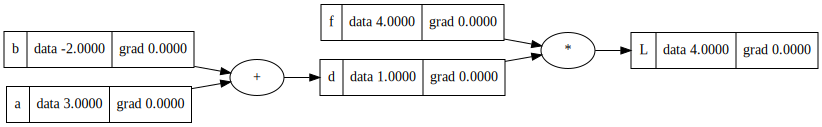

In [6]:
draw_dot(L)

dl/da=(dl/dd)*(dd/da)
= 4 * 1

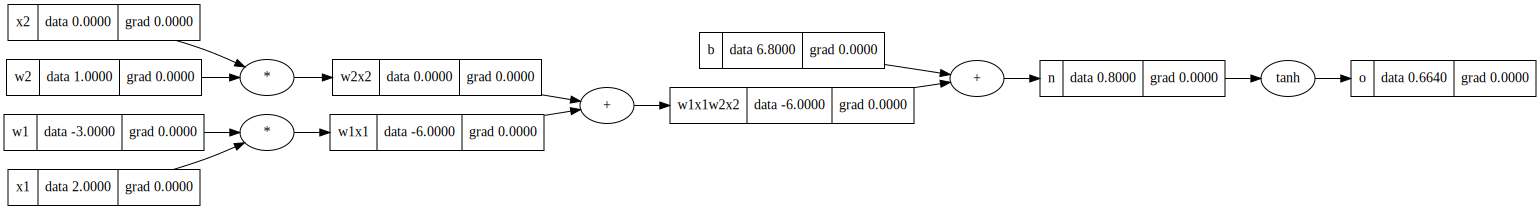

In [7]:
#inputs x1,x2
x1=value(2.0,label='x1')
x2=value(0.0,label='x2')
#weights w1, w2
w1 = value(-3.0,label='w1')
w2= value(1.0,label='w2')
# bias b
b= value(6.8,label='b')
#w1x1
w1x1=w1*x1;w1x1.label='w1x1'
w2x2=w2*x2;w2x2.label='w2x2'
# adding the result
w1x1w2x2=w1x1+w2x2; w1x1w2x2.label='w1x1w2x2'
n= w1x1w2x2 +b; n.label='n'
#passing through activation function
o=n.tanh();o.label='o'
draw_dot(o)

In [8]:
o.backward()

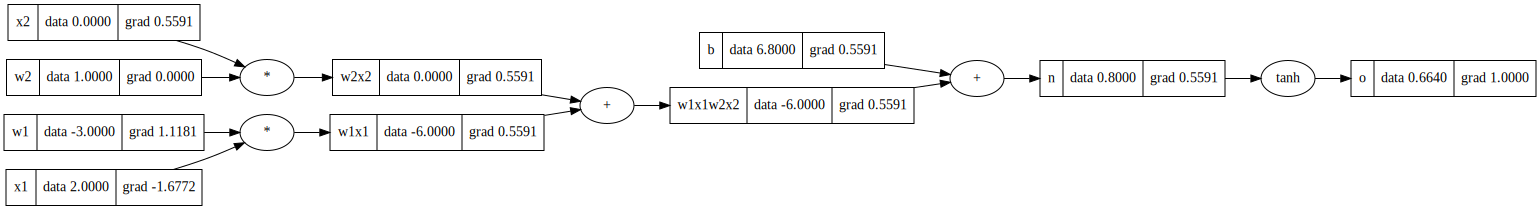

In [9]:
draw_dot(o)

In [10]:
import torch

In [11]:
w1= torch.Tensor([-3.0]).double() ; w1.requires_grad=True
x1=torch.Tensor([2.0]).double(); x1.requires_grad=True
x2=torch.Tensor([0.0]).double(); x2.requires_grad=True
w2=torch.Tensor([1.0]).double();w2_requires_grad=True
b=torch.Tensor([6.8]).double();b.requires_grad=True
n=w1*x1 + w2*x2 + b;n.retain_grad()
o=torch.tanh(n); o.retain_grad()
o.backward()
print(o.data.item())
o.backward

0.6640368768991465


<bound method Tensor.backward of tensor([0.6640], dtype=torch.float64, grad_fn=<TanhBackward0>)>

In [12]:
print(w1.grad.item())

1.1181100522360556


In [13]:
import random

In [14]:

class Neuron:
  def __init__(self,nin):
    self.w=[(value(random.uniform(-1,1))) for _ in range(nin)]
    self.b=value(random.uniform(-1,1))
  def __call__(self,x):
    out=sum((w*x for w,x in zip(self.w,x)),self.b)
    return out.tanh()
  def parameters(self):
    return self.w + [self.b]
class Layer:
  def __init__(self,nin,nout):
    self.neurons=[Neuron(nin) for _ in range(nout)]
  def __call__(self,x):
    outs=[n(x) for n in self.neurons]
    return outs[0] if(len(outs)==1) else outs
  def parameters(self):
    return [p for n in self.neurons for p in n.parameters()]
    params=[]
    for neurons in self.neurons:
      params+=neurons.parameters()
    return params
class MLP:
  def __init__(self,nin,nouts):
    sz= [nin]+nouts
    self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
  def __call__(self,x):
    for layer in self.layers:
      x=layer(x)
    return x
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [15]:
n= MLP(3,[4,4,1])#TRYING OUR MODEL

In [16]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # targets


In [17]:
y_pred = [n(x) for x in xs]
y_pred

[(value=-0.8715918449847198),
 (value=0.1251702898636654),
 (value=-0.7679493511843485),
 (value=-0.058798398614041854)]

In [18]:
loss = sum((yz-ygt)**2 for yz,ygt in zip(y_pred,ys))
loss

(value=5.943765767928616)

In [19]:
n.parameters()

[(value=-0.6871790657301442),
 (value=-0.14566849695702055),
 (value=-0.23248506817222214),
 (value=0.7141274919512997),
 (value=-0.50376372304395),
 (value=-0.4519796464915322),
 (value=-0.02681498417175554),
 (value=0.03557011087492179),
 (value=-0.22872146831252516),
 (value=-0.9607064179936602),
 (value=-0.8824775146701163),
 (value=0.6351285773823196),
 (value=0.27186627040182243),
 (value=-0.9245840488712331),
 (value=-0.2899398841312171),
 (value=0.22473285711060087),
 (value=-0.6665069173048819),
 (value=-0.7729337968449066),
 (value=-0.42690386124171575),
 (value=-0.6423194542998807),
 (value=-0.796747571853647),
 (value=0.745291302742813),
 (value=-0.5679544829475225),
 (value=-0.6621394630094717),
 (value=0.8016704458965085),
 (value=0.43356513429195487),
 (value=0.661375473969007),
 (value=0.0705519444563012),
 (value=0.1077812034949297),
 (value=0.1032271119340531),
 (value=0.032166636401451454),
 (value=0.3363829175928197),
 (value=-0.9540851434452853),
 (value=-0.9388153

In [20]:
len(n.parameters())

41

In [21]:
for p in n.parameters():
  p.data+= -0.01*p.grad  #update weights

In [22]:
m=MLP(3,[4,4,1])

In [23]:
m.parameters()

[(value=-0.8745495559211669),
 (value=-0.3421255390089111),
 (value=-0.7718904469639358),
 (value=-0.6060088632281255),
 (value=0.1811624687889266),
 (value=0.598830788158393),
 (value=-0.8450969367176633),
 (value=0.08372558383072404),
 (value=-0.9397032905704426),
 (value=0.2875149644677166),
 (value=-0.10309159015947356),
 (value=-0.6735663738682607),
 (value=0.08334833469081793),
 (value=0.1017553558175559),
 (value=-0.1618211528343776),
 (value=-0.5393659107127462),
 (value=0.8438755525149841),
 (value=-0.7780669391541051),
 (value=0.04990002185347797),
 (value=-0.8583422392500888),
 (value=0.6021372933041749),
 (value=-0.33653785367319133),
 (value=-0.6273501865142759),
 (value=-0.33564416308891754),
 (value=0.8199350799446619),
 (value=0.16548017597729747),
 (value=-0.2269828106291687),
 (value=-0.9455881616067932),
 (value=0.6769467271476988),
 (value=0.14274438613038587),
 (value=0.3005176347012255),
 (value=-0.13772752083139328),
 (value=-0.7514726800724647),
 (value=0.450638

In [24]:
history_loss=[]

In [25]:
for k in range(100):
  #forward pass
  y_pred= [m(x) for x in xs]
  loss= sum((yz-ygt)**2 for yz,ygt in zip(y_pred,ys))
  #backward pass
  for p in m.parameters():
    p.grad=0.0
  loss.backward()
  for p in m.parameters():
    p.data+= -0.05*p.grad
  history_loss.append(loss.data)
  print(f"{k}. {loss.data}")

0. 3.8514474057534978
1. 0.5841087161543964
2. 0.24059397324413612
3. 0.18312214911385766
4. 0.14836568531451752
5. 0.12444515718267712
6. 0.10689494935291854
7. 0.09347196690129787
8. 0.08288775540843558
9. 0.07434095568066398
10. 0.06730504943343624
11. 0.061419472962209405
12. 0.056429029160711575
13. 0.052148115960810246
14. 0.04843861068935242
15. 0.045195675879510996
16. 0.04233835945500437
17. 0.039803201006995984
18. 0.03753978048579701
19. 0.03550755516885977
20. 0.033673570859024796
21. 0.032010778528112724
22. 0.03049677796436091
23. 0.029112867559269135
24. 0.0278433168741671
25. 0.026674803542373733
26. 0.02559597291321957
27. 0.024597090427322783
28. 0.023669764794692325
29. 0.022806725764719753
30. 0.022001644373524337
31. 0.021248986523878837
32. 0.020543892929657685
33. 0.01988208006861246
34. 0.01925975799232959
35. 0.018673561751265597
36. 0.01812049388429039
37. 0.017597875952436812
38. 0.017103307506213604
39. 0.016634631194563813
40. 0.01618990297319341
41. 0.0157

In [26]:
y_pred

[(value=0.9654514561056552),
 (value=-0.9668929220266527),
 (value=-0.9527955850808377),
 (value=0.9601591089192447)]

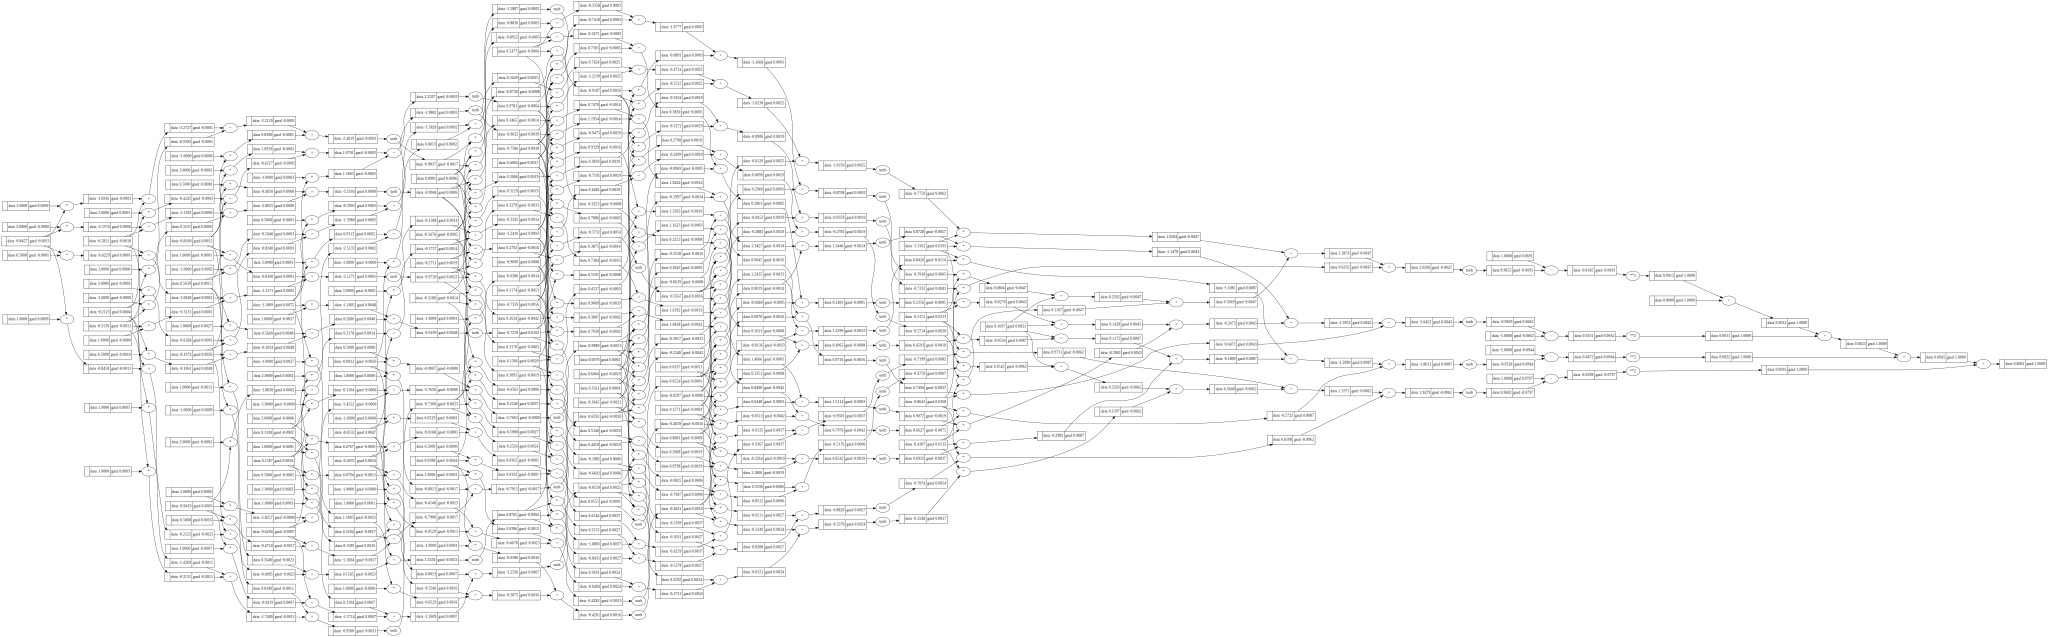

In [27]:
draw_dot(loss)

COMPARISION BETWEEN NUMPY AND PYTORCH

In [28]:
init_weights = [p.data for p in n.parameters()]

In [29]:
import torch.nn as nn

In [30]:
class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 4), nn.Tanh(),
            nn.Linear(4, 4), nn.Tanh(),
            nn.Linear(4, 1), nn.Tanh(),
        )
    def forward(self, x):
        return self.net(x)

torch_model = TorchMLP()

In [31]:
idx = 0
with torch.no_grad():
    for layer in [torch_model.net[0], torch_model.net[2], torch_model.net[4]]:
        nout, nin = layer.weight.shape
        for i in range(nout):
            for j in range(nin):
                layer.weight[i, j] = init_weights[idx]; idx += 1
            layer.bias[i] = init_weights[idx]; idx += 1

X = torch.tensor(xs, dtype=torch.float32)
y = torch.tensor(ys, dtype=torch.float32).view(-1, 1)


In [32]:
torch_losses = []
for step in range(100):
    ypred_t = torch_model(X)
    loss_t  = ((ypred_t - y) ** 2).sum()
    torch_model.zero_grad()
    loss_t.backward()
    with torch.no_grad():
        for p in torch_model.parameters():
            p -= 0.1 * p.grad
    torch_losses.append(loss_t.item())

In [33]:
import matplotlib.pyplot as plt


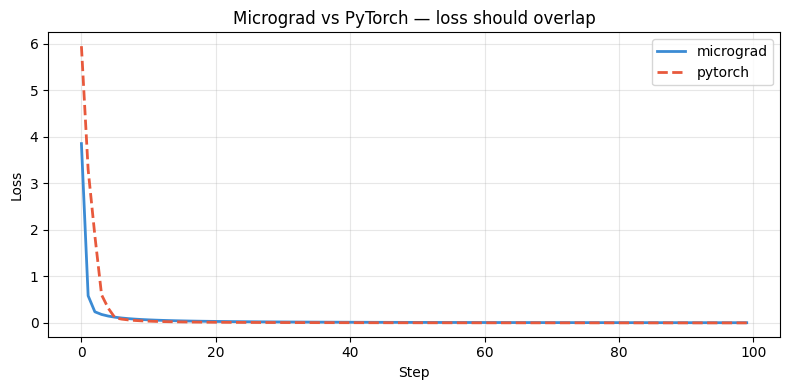

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(history_loss, label='micrograd', linewidth=2, color='#3B8BD4')
plt.plot(torch_losses, label='pytorch',   linewidth=2, color='#E8593C', linestyle='--')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Micrograd vs PyTorch — loss should overlap')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()